In [1]:
#from os import system
#system('conda install -y -c conda-forge ipympl')

In [2]:
%matplotlib ipympl
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
import numpy as np
from random import randint, choice


In [3]:
# Colorblind-friendly palette
colors:dict[str,str] = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
}

In [4]:
class EDString:
    chain:list[set[str]]

    def __init__(self,size:int=12):
        self.size = size
        self.chain = [set() for _ in range(self.size)]

    def add_read(self,read:str):
        if self.size != len(read):
            raise ValueError("Read size not compatible with EDString size")
        else:
            for i in range(len(read)):
                self.chain[i].add(read[i])

    def is_empty(self):
        return any([x==set() for x in self.chain])

    def get_weights(self) -> tuple[int]:
        """renvoie les abondances relatives en nucléotides et le taux de dégénérescence

        Returns:
            tuple[int]: renvoie un tuple de valeurs entre 0 et 1 (1 = condition saturée) avec dans l'ordre : [A*,T*,C*,G*,N*]
        """
        w:list[float] = [sum([1 if c in x else 0 for x in self.chain])/self.size for c in ['A','T','C','G']]
        sum_coeffs:float = sum(w)
        w = [s/sum_coeffs for s in w]
        degen:float = sum([len(x)-1 for x in self.chain])/(self.size*3)
        return (*w,degen)

    def __str__(self):
        edstr:list[str] = list()
        for x in self.chain:
            if len(x) == 0:
                edstr.append('∅')
            elif len(x) == 1:
                edstr.append(list(x)[0])
            else:
                edstr.append("{"+'·'.join(x)+"}")
        return ' '.join(edstr)
    
    def randomize(self,reads_to_randomize:int = 4):
        for _ in range(randint(1,reads_to_randomize)):
            self.add_read(''.join([choice(['A','T','C','G']) for _ in range(self.size)]))


In [5]:
maSuperString = EDString(10)
maSuperString.randomize(2)
print(maSuperString)
print(maSuperString.get_weights())

{C·A} {C·T} {A·G} {C·T} C {T·G} {C·T} {C·A} {T·G} A
(0.22222222222222224, 0.2777777777777778, 0.3333333333333333, 0.16666666666666666, 0.26666666666666666)


Il faut partir des breakpoints au graph-level
- on calcule les positions sur chaque fasta
- on extrait les morceaux de séquence au fur et à mesure
- on augmente les ed-strings
- on clusterise les ed-strings en fonction de leur distance (ou de leur contenu)

In [6]:
def dist(a:EDString,b:EDString) -> float:
    """Calcule la distance 

    Args:
        a (EDString): _description_
        b (EDString): _description_

    Returns:
        float: distance computed between the two ed-strings
    """
    return sum()

In [7]:
def compute_coordinates(weights:tuple) -> list:
    try:
        x = (weights[0]/(weights[0]+weights[1])*2)-1
    except:
        # contient ni C ni G
        x = .5
    try:
        y = (weights[2]/(weights[2]+weights[3])*2)-1
    except:
        y = .5
    return [x,y,(weights[-1]*2)-1]

In [8]:
from os import listdir
from json import load
from Bio import SeqIO


all_edits:dict = load(open("dist.json","r"))


# charger les fasta
all_genomes:dict = dict()
for file in listdir("genomes/"):
    with open("genomes/"+file) as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if '#' in record.id:
                all_genomes[record.id.split('#')[0]] = record.seq
            else:
                all_genomes[record.id] = record.seq

print(list(all_genomes.keys()))

['CASBJG01', 'CASBJQ01', 'CASBJL01', 'CASBJH01', 'CASBJN01', 'CASBIW01', 'CASBJM01', 'CASBIZ01', 'CASBJJ01', 'CASBJT01', 'CASBJU01', 'CASBJI01', 'CASBJV01', 'CASBIT01', 'CASBJS01']


In [9]:
from random import sample

ed_strings:list = list()
eds_length:int = 20
flag:bool = False

print(len(all_edits['splits']))
print(len(all_edits['merges']))
print(len(all_edits['equiv']))

for edit in sample(all_edits['splits'],len(all_edits['merges'])):
    ed_strings.append(EDString(eds_length))
    # chaque edit correspond à 1 ed-string
    for path_name,path_positions,_ in edit:
        try:
            pp = path_positions[0]
            ed_strings[-1].add_read(all_genomes[path_name][pp-int(eds_length/2):pp+int(eds_length/2)])
        except:
            # je ne veux pas à avoir à gérer les bordures
            pass

19657
13625
30059


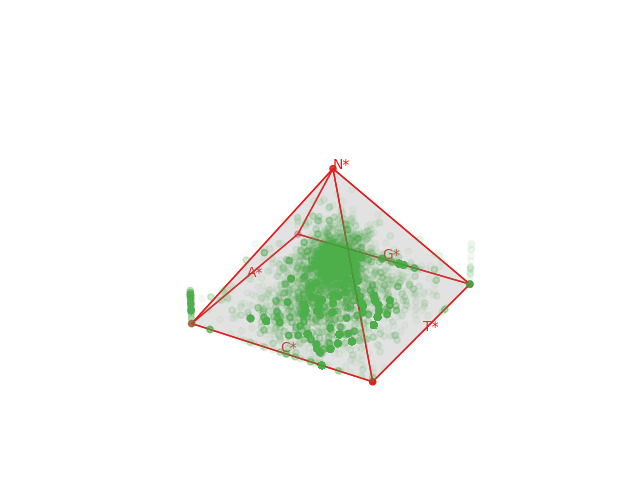

In [10]:
#%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Hide grid lines
ax.grid(False)
plt.axis('off')
# Hide axes ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# vertices of a pyramid
v = np.array([[-1, -1, -1], [1, -1, -1], [1, 1, -1],  [-1, 1, -1], [0, 0, 1]])
ax.scatter3D(v[:, 0], v[:, 1], v[:, 2],color=colors['red'])

# generate list of sides' polygons of our pyramid
verts = [ [v[0],v[1],v[4]], [v[0],v[3],v[4]],
 [v[2],v[1],v[4]], [v[2],v[3],v[4]], [v[0],v[1],v[2],v[3]]]

# plot sides
ax.add_collection3d(Poly3DCollection(verts, 
 facecolors=colors['gray'], linewidths=1, edgecolors=colors['red'], alpha=.15))

v2 = np.array([[-1, 0, -1], [0, -1, -1], [1, 0, -1],  [0, 1, -1], [0, 0, 1]])
texts:list = ["A*","C*","T*","G*","N*"]
for i,(x,y,z) in enumerate(v2):
    ax.text(x, y, z, texts[i], color=colors['red'])


# inserting ED-strings
weds:list = list()
for ed in ed_strings:
    if not ed.is_empty():
        try:
            weds.append(compute_coordinates(ed.get_weights()))
        except:
            print(ed)

weds = np.array(weds)
#weds = np.array([compute_coordinates(ed.get_weights()) for ed in ed_strings if not ed.is_empty()])
ax.scatter3D(weds[:, 0], weds[:, 1], weds[:, 2],color=colors['green'],alpha=.05)

plt.show()